<a href="https://colab.research.google.com/github/shaurya25007212-droid/MLE/blob/main/Case_Study_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

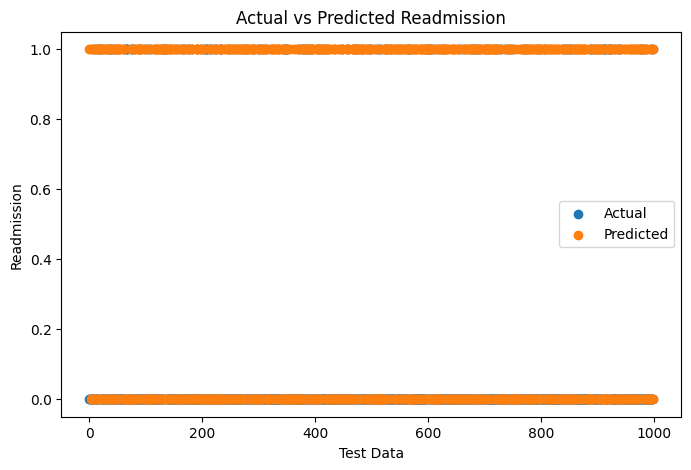

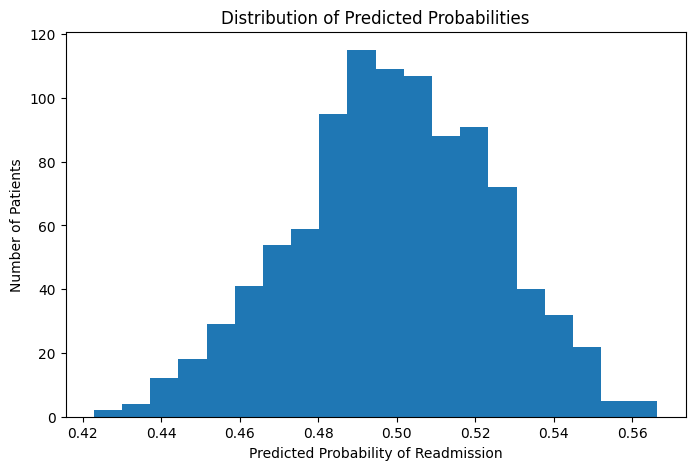

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


df = pd.read_csv("train_df.csv")
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)



model.fit(X_train, y_train)



y_prob = model.predict_proba(X_test)[:, 1]


y_pred = (y_prob >= 0.5).astype(int)

plt.figure(figsize=(8, 5))

plt.scatter(
    range(len(y_test)),
    y_test,
    label="Actual"
)

plt.scatter(
    range(len(y_test)),
    y_pred,
    label="Predicted"
)

plt.xlabel("Test Data")
plt.ylabel("Readmission")
plt.title("Actual vs Predicted Readmission")
plt.legend()

plt.show()

plt.figure(figsize=(8, 5))

plt.hist(y_prob, bins=20)

plt.xlabel("Predicted Probability of Readmission")
plt.ylabel("Number of Patients")
plt.title("Distribution of Predicted Probabilities")

plt.show()

Confusion Matrix:
[[413 399]
 [ 96  92]]

True Negative (TN): 413
False Positive (FP): 399
False Negative (FN): 96
True Positive (TP): 92

     EVALUATION METRICS
Accuracy : 0.505
Precision: 0.1874
Recall   : 0.4894
F1 Score : 0.271
ROC-AUC  : 0.5073

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.51      0.63       812
           1       0.19      0.49      0.27       188

    accuracy                           0.51      1000
   macro avg       0.50      0.50      0.45      1000
weighted avg       0.69      0.50      0.56      1000



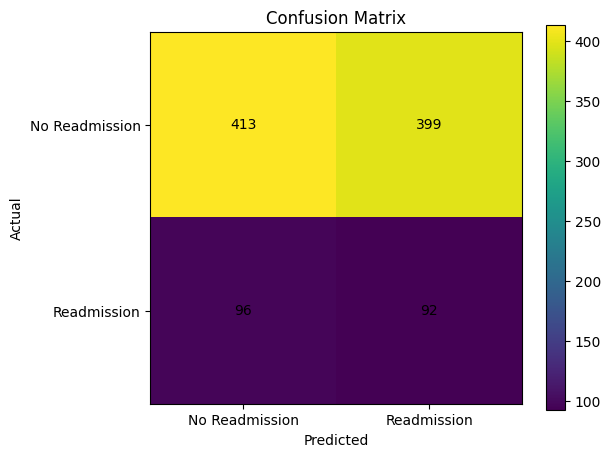

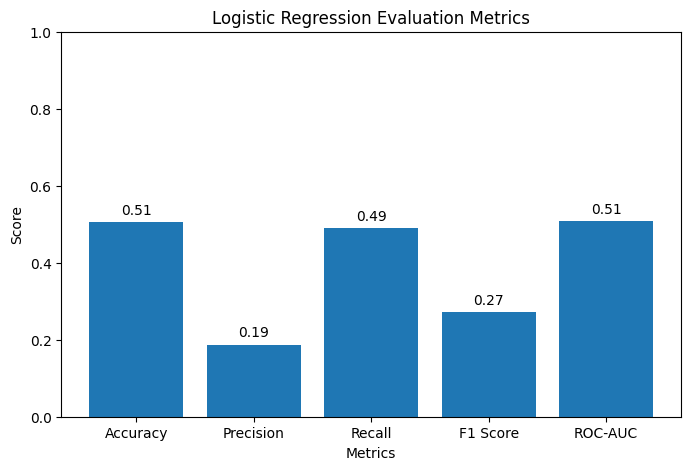

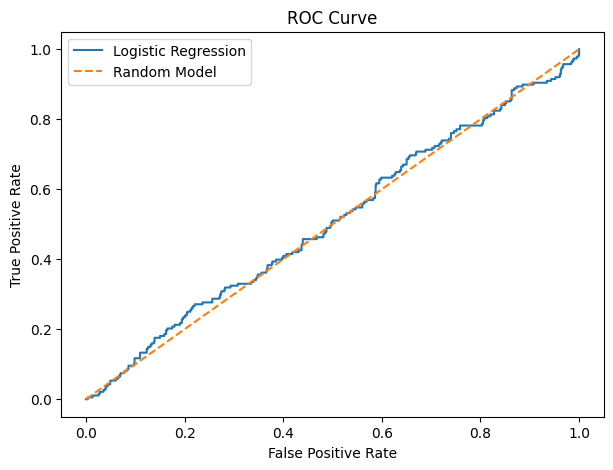

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nTrue Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


print("\n==============================")
print("     EVALUATION METRICS")
print("==============================")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))


print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Readmission", "Readmission"]
)

plt.yticks(
    [0, 1],
    ["No Readmission", "Readmission"]
)


# Display numbers inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

values = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]


plt.figure(figsize=(8, 5))

plt.bar(metrics, values)

plt.ylim(0, 1)

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Logistic Regression Evaluation Metrics")


for i, value in enumerate(values):
    plt.text(
        i,
        value + 0.02,
        round(value, 2),
        ha="center"
    )

plt.show()

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)


plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Model"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()